In [1]:
import re, os
import burnman
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import planetary_grid_reader as pgr
import geotherm_calculator as gc
import habitability_calculator as hc

from astropy import constants as const
from matplotlib.patches import Patch
from burnman import minerals, Composite,Composition, Layer, Planet, Mineral
from burnman.tools.chemistry import formula_mass

# Librería IAPWS para propiedades del agua
from iapws import IAPWS95
from iapws.iapws97 import IAPWS97
from iapws.iapws08 import _Tf, _Tb, _Triple
from iapws._iapws import _Sublimation_Pressure, _Melting_Pressure

In [2]:
Gpa = 1e9
Mpa = 1e6
km = 1e3
to = 1.386e9 #Terrestrial Oceans volume in km3
G = const.G.value # Gravitational constant (m3 kg-1 s-2)
g_earth = const.g0.value # Surface gravity Earth (m s-2)

Me = const.M_earth.value # Earth mass (kg) 
Re = const.R_earth.value # Earth radius (m) 

Lsun = const.L_sun.value # Solar luminosity (W)
au = const.au.value # Astronomical Unit (m)

hc_earth = 35  #km
hr_earth = np.array([0.25, 0.35])*hc_earth 


In [21]:
def surface_pressure(M_planet,
                     M_ref=Me,
                     P0_ref=1.01325e5):
    """
    Escala la presión atmosférica superficial para planetas tipo Tierra.
    
    p0 ∝ M^0.92  (atmósfera tipo Tierra)
    """
    return P0_ref * (M_planet / M_ref)**0.92

def Graficos(df_geotherm, liquid_zone_data, habitable_zone_data):
    
# =============================================================================
# GRÁFICOS P-T, P-depth y T-depth CON ZONAS DE HABITABILIDAD
# =============================================================================

    fig = plt.figure(figsize=(25, 10))
    gs = fig.add_gridspec(1, 3, hspace=0.3, wspace=0.3)

    ax1 = fig.add_subplot(gs[0, 0])  # Diagrama P-T
    ax2 = fig.add_subplot(gs[0, 1])  # P-depth
    ax3 = fig.add_subplot(gs[0, 2])  # T-depth

    # Extraer datos
    z = df_geotherm['depth_km'].values
    T = df_geotherm['T_K'].values
    P = df_geotherm['P_Pa'].values / 1e6  # Convertir a MPa

    # Datos de zonas (de cálculos anteriores)
    z_water = liquid_zone_data['liquid_zone'] / 1000  # km
    T_water = liquid_zone_data['T_liquid']  # K
    P_water = liquid_zone_data['P_liquid'] / 1e6  # MPa

    z_hab = habitable_zone_data['habitable_zone'] / 1000  # km
    T_hab = habitable_zone_data['T_habitable']  # K
    P_hab = habitable_zone_data['P_habitable'] / 1e6  # MPa

    # Extract only the values corresponding to the liquid water zone
    T_melt = liquid_zone_data['T_melt'] #K
    T_boil = liquid_zone_data['T_boil'] #K
    T_melt_water = T_melt[:len(P_water)]  # Slice to match P_water length
    T_boil_water = T_boil[:len(P_water)]  # Slice to match P_water length

    # Filter out NaN values for valid melting curve
    mask_valid_melt = ~np.isnan(T_melt_water)
    P_melt_valid = P_water[mask_valid_melt]
    T_melt_valid = T_melt_water[mask_valid_melt]

    # Límites biológicos
    T_bio_max = 394.0  # K (121°C)
    P_bio_max = 110.0  # MPa

    # =============================================================================
    # PANEL 1: DIAGRAMA P-T
    # =============================================================================

    # Región de agua líquida (entre fusión y ebullición)
    T_fill = np.concatenate([T_melt_valid, T_boil_water[::-1]])
    P_fill = np.concatenate([P_melt_valid, P_water[::-1]])
    ax1.fill(T_fill, P_fill, color='lightskyblue', alpha=0.4, 
            label='Liquid Water', zorder=1)

    # Región habitable (limitada por T_bio y P_bio)
    T_hab_clipped = T_hab[T_hab <= T_bio_max]
    P_hab_clipped = P_hab[:len(T_hab_clipped)]
    # Obtener T_melt para la zona habitable (usar los mismos índices)
    T_melt_hab_clipped = T_melt_valid[:len(T_hab_clipped)]
    T_fill_hab = np.concatenate([T_melt_hab_clipped, T_hab_clipped[::-1]])
    P_fill_hab = np.concatenate([P_hab_clipped, P_hab_clipped[::-1]])
    ax1.fill(T_fill_hab, P_fill_hab, color='lightgreen', alpha=0.5,
            label='Habitable Zone', zorder=2)

    # Curvas de fase
    ax1.plot(T_melt_valid, P_melt_valid, 'b-', linewidth=2.5, 
            label='Fusion (IAPWS)', zorder=3)
    ax1.plot(T_boil_water, P_water, 'r-', linewidth=2.5, 
            label='Boiling (IAPWS)', zorder=3)

    # Geothermal profile
    ax1.plot(T, P, 'k-', linewidth=3, label='Geothermal Profile', zorder=4)
    # Biological limits
    ax1.axvline(T_bio_max, color='orange', linestyle='--', linewidth=2.5, 
                label=f'$T_{{bio}}$ = {T_bio_max:.0f} K\n(121°C)', zorder=5)
    ax1.axhline(P_bio_max, color='purple', linestyle='--', linewidth=2.5,
                label=f'$P_{{bio}}$ = {P_bio_max:.0f} MPa\n(1100 bar)', zorder=5)

    # Configuration
    ax1.set_xlabel('Temperature [K]', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Pressure [MPa]', fontsize=13, fontweight='bold')
    #ax1.set_title('P-T Diagram\nLiquid Water and Habitable Zones', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper left', fontsize=9, framealpha=0.95)
    ax1.grid(True, alpha=0.3, linestyle=':', linewidth=0.7)
    ax1.set_xlim(min(T)*0.9, max(T) + 50)
    ax1.set_ylim(0, max(P_water)*1.1)

    # =============================================================================
    # PANEL 2: PERFIL P-depth
    # =============================================================================

    # Zona de agua líquida
    ax2.axhspan(z_water[0], z_water[-1], color='lightskyblue', alpha=0.4,
                label='Liquid Water', zorder=1)

    # Zona habitable
    ax2.axhspan(z_hab[0], z_hab[-1], color='lightgreen', alpha=0.5,
                label='Habitable Zone', zorder=2)
    # Perfil de presión
    ax2.plot(P, z, 'purple', linewidth=3, label='P(z)', zorder=3)

    # Límite biológico de presión
    #ax2.axvline(P_bio_max, color='purple', linestyle='--', linewidth=2.5, label=f'$P_{{bio}}$ = {P_bio_max:.0f} MPa', zorder=4)

    # Marcar fronteras
    ax2.axhline(z_hab[0], color='green', linestyle=':', linewidth=2, alpha=0.7)
    ax2.axhline(z_hab[-1], color='red', linestyle=':', linewidth=2, alpha=0.7)

    # Configuración
    ax2.set_xlabel('Pressure [MPa]', fontsize=13, fontweight='bold')
    ax2.set_ylabel('Depth [km]', fontsize=13, fontweight='bold')
    #ax2.set_title('P-depth Profile\nPressure vs Depth', fontsize=14, fontweight='bold')
    ax2.invert_yaxis()
    ax2.legend(loc='lower right', fontsize=9, framealpha=0.95)
    ax2.grid(True, alpha=0.3, linestyle=':', linewidth=0.7)
    ax2.set_xlim(0, P_bio_max)
    ax2.set_ylim(z_water[-1]*1.1, 0)

    # =============================================================================
    # PANEL 3: PERFIL T-depth
    # =============================================================================

    # Zona de agua líquida
    ax3.axhspan(z_water[0], z_water[-1], color='lightskyblue', alpha=0.4,
                label='Liquid Water', zorder=1)

    # Zona habitable
    ax3.axhspan(z_hab[0], z_hab[-1], color='lightgreen', alpha=0.5,
                label='Habitable Zone', zorder=2)
    # Perfil de temperatura
    ax3.plot(T, z, 'red', linewidth=3, label='T(z) Profile', zorder=3)

    # Límite biológico de temperatura
    #ax3.axvline(T_bio_max, color='orange', linestyle='--', linewidth=2.5, label=f'$T_{{bio}}$ = {T_bio_max:.0f} K', zorder=4)

    # Marcar fronteras
    ax3.axhline(z_hab[0], color='green', linestyle=':', linewidth=2, alpha=0.7)
    ax3.axhline(z_hab[-1], color='red', linestyle=':', linewidth=2, alpha=0.7)

    # Configuración
    ax3.set_xlabel('Temperature [K]', fontsize=13, fontweight='bold')
    ax3.set_ylabel('Depth [km]', fontsize=13, fontweight='bold')
    #ax3.set_title('T-depth Profile\nTemperature vs Depth', fontsize=14, fontweight='bold')
    ax3.invert_yaxis()
    ax3.legend(loc='lower right', fontsize=9, framealpha=0.95)
    ax3.grid(True, alpha=0.3, linestyle=':', linewidth=0.7)
    ax3.set_xlim(min(T), T_bio_max)
    ax3.set_ylim(z_water[-1]*1.1, 0)

    plt.tight_layout()
    plt.show()


### TRAPPIST 1-e

In [7]:
Mte = 0.692 * Me
Rte = 0.92 * Re
gte = G * Mte / Rte**2
Lt = 0.000566 
d = 0.02925
hc_te = hc_earth * (gte / g_earth)**-1
hr_te = np.array([0.25, 0.35]) * hc_te
Asurf_te = 1.5e-6
Amant_te = 3e-8
Tsurf = hc.T_eq(L_star=Lt, distance_AU=d, albedo=0.20, tau=0.3)
rho_top = 2900



In [4]:
COMPOSITION_TRAPPIST1E = {
    "upper": {
        "Quartz": 5,
        "Orthoclase": 2,
        "Albite": 20,
        "Anorthite": 25,
        "Hornblende": 25,
        "Diopside": 8,
        "Enstatite": 5,
        "Ferrosillite": 3,
        "Forsterite": 5,
        "Fayalite": 2
    },

    "middle": {
        "Quartz": 3,
        "Orthoclase": 1,
        "Albite": 18,
        "Anorthite": 30,
        "Hornblende": 30,
        "Diopside": 8,
        "Enstatite": 5,
        "Ferrosillite": 3,
        "Forsterite": 2
    },

    "lower": {
        "Quartz": 1,
        "Orthoclase": 0,
        "Albite": 10,
        "Anorthite": 35,
        "Hornblende": 35,
        "Diopside": 10,
        "Enstatite": 6,
        "Ferrosillite": 3
    },

    "mantle": {
        "Forsterite": 55,
        "Fayalite": 8,
        "Enstatite": 18,
        "Ferrosillite": 4,
        "Diopside": 10,
        "Almandine": 5
    }
}

mineral_objects = gc.get_mineral_objects()
rocks = gc.prepare_rocks_dict(composition=COMPOSITION_TRAPPIST1E,mineral_objects=mineral_objects)

In [10]:
Ptop = surface_pressure(M_planet=Mte)

geo_trappist1e = gc.calculate_geotherm(
        rocks=rocks,
        q_s=65e-3,           # 65 mW/m²
        z_max=30e3,         # 10 km 
        dz=100.0,           
        R_planet=Rte,
        M_total=Mte,
        boundaries=gc.scale_layer_boundaries(R_planet=Rte),
        T_top=Tsurf,
        P_top=Ptop,
        rho_top=rho_top,
        A_surface=Asurf_te,
        A_mantle=Amant_te,
        h_r=12,
    )

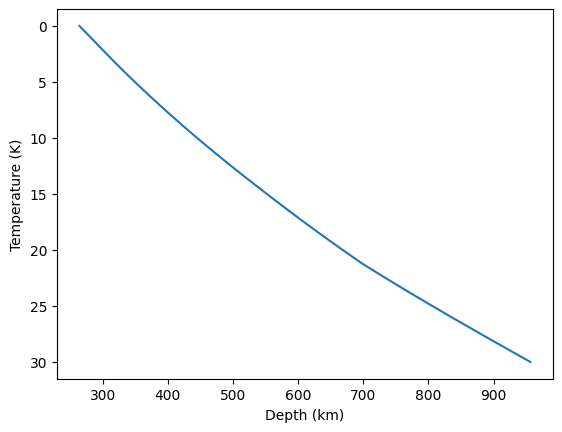

In [16]:
plt.plot( geo_trappist1e['T_K'], geo_trappist1e['depth_km'])
plt.xlabel('Depth (km)')
plt.ylabel('Temperature (K)')
plt.gca().invert_yaxis()
plt.show()


C:\Users\Santiago\AppData\Local\Temp\ipykernel_21544\2358675539.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


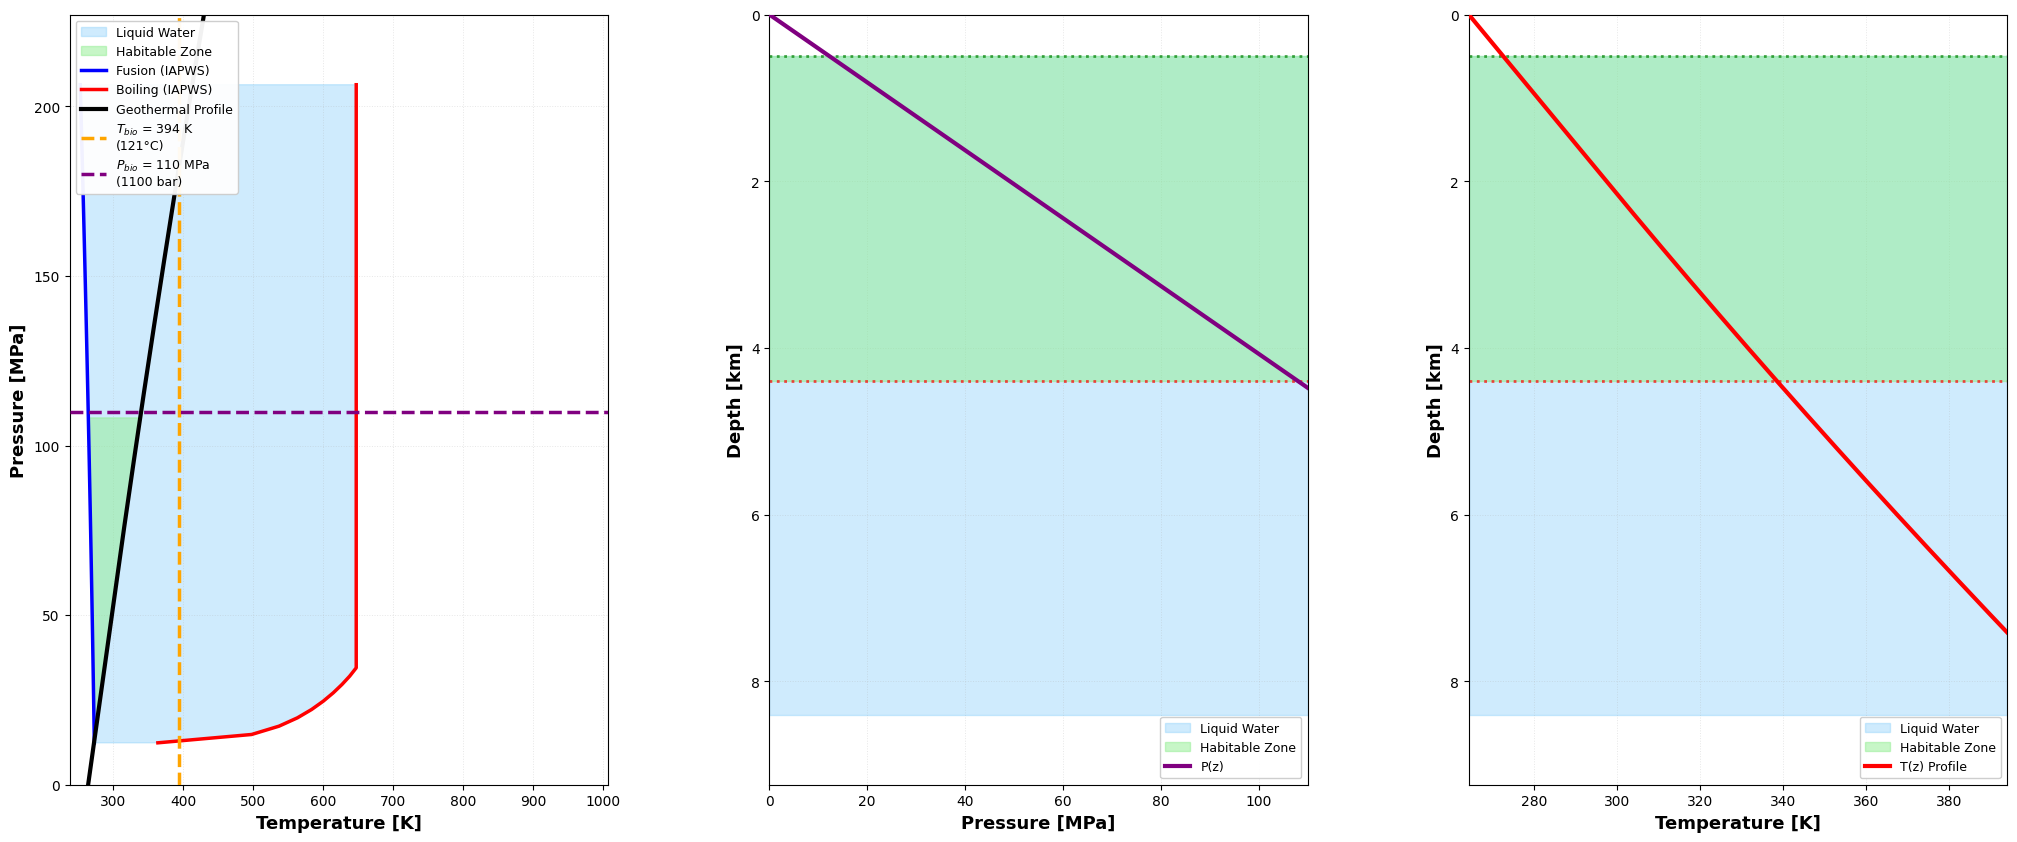


💧 ZONA DE AGUABILIDAD (Agua Líquida):
   Profundidad: 0.50 - 8.40 km
   Temperatura: 272.69 - 413.06 K
   Presión: 12.36 - 206.40 MPa
   Espesor: 7.900 km

🦠 ZONA HABITABLE (Límites Biológicos):
   Profundidad: 0.50 - 4.40 km
   Temperatura: 272.69 - 338.63 K (-0.5 - 65.5°C)
   Presión: 12.36 - 108.16 MPa
   Espesor: 3.900 km

📊 Zona Habitable = 49.4% de la Zona de Aguabilidad



In [22]:
liquid_zone_data = hc.find_liquid_zone(geo_trappist1e, salinity=0.0)
habitable_zone_data = hc.find_habitable_zone(liquid_zone_data['indices'], geo_trappist1e)

Graficos(geo_trappist1e, liquid_zone_data, habitable_zone_data)
hc.liq_hab_zone_data(liquid_zone_data, habitable_zone_data)